## Import Dependencies

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from numpy import mean
import matplotlib.pyplot as plt
from datasets import load_dataset
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [ ]:
!pip install transformers torch

from transformers import AutoTokenizer, AutoModel
import torch

## Load the Dataset

In [ ]:
ds = load_dataset("TheFinAI/CLEF_Task3_Trading")

In [ ]:
print(ds)

DatasetDict({
    BTC: Dataset({
        features: ['date', 'asset', 'prices', 'news', '10k', '10q', 'momentum', 'future_price_diff'],
        num_rows: 269
    })
    TSLA: Dataset({
        features: ['date', 'asset', 'prices', 'news', '10k', '10q', 'momentum', 'future_price_diff'],
        num_rows: 269
    })
})


In [ ]:
df1 = ds['BTC'].to_pandas()
df1.head()

,date,asset,prices,news,10k,10q,momentum,future_price_diff
0,2025-08-01,BTC,113343.12,"[On August 1, 2025, the BTC news landscape pre...",[],[],bearish,-558.16
1,2025-08-02,BTC,112784.96,"[On August 2, 2025, the BTC news landscape pre...",[],[],bearish,1341.66
2,2025-08-03,BTC,114126.62,"[On August 3, 2025, the BTC news landscape pre...",[],[],bearish,1049.57
3,2025-08-04,BTC,115176.19,[The collection of BTC-focused articles from 2...,[],[],bullish,-984.70
4,2025-08-05,BTC,114191.49,[The collection of BTC-focused articles from A...,[],[],bullish,863.17


In [ ]:
df2 = ds['TSLA'].to_pandas()
df2.head()

,date,asset,prices,news,10k,10q,momentum,future_price_diff
0,2025-08-01,TSLA,302.630005,"[On August 1, 2025, a broad set of Tesla-relat...",[],[],bearish,0.000000
1,2025-08-02,TSLA,302.630005,"[On 2025-08-02, a slate of articles touching T...",[],[],bearish,0.000000
2,2025-08-03,TSLA,302.630005,[On the set of TSLA-related news items dated 2...,[],[],bearish,6.630005
3,2025-08-04,TSLA,309.260010,"[The August 4, 2025 coverage of Tesla and Elon...",[],[],bullish,-0.540009
4,2025-08-05,TSLA,308.720001,[Across the TSLA-related articles published on...,[],[],bullish,11.190002


## Pre-processing

Mergining both the dataframes - BTC and TSLA

In [ ]:
frames = [df1, df2]
df = pd.concat(frames)
df.head()

,date,asset,prices,news,10k,10q,momentum,future_price_diff
0,2025-08-01,BTC,113343.12,"[On August 1, 2025, the BTC news landscape pre...",[],[],bearish,-558.16
1,2025-08-02,BTC,112784.96,"[On August 2, 2025, the BTC news landscape pre...",[],[],bearish,1341.66
2,2025-08-03,BTC,114126.62,"[On August 3, 2025, the BTC news landscape pre...",[],[],bearish,1049.57
3,2025-08-04,BTC,115176.19,[The collection of BTC-focused articles from 2...,[],[],bullish,-984.70
4,2025-08-05,BTC,114191.49,[The collection of BTC-focused articles from A...,[],[],bullish,863.17


In [ ]:
df.shape

(538, 8)

In [ ]:
df.dtypes

,0
date,object
asset,object
prices,float64
news,object
10k,object
10q,object
momentum,object
future_price_diff,float64


In [ ]:
df['future_price_diff'] = pd.to_numeric(df['future_price_diff'], errors='coerce')

In [ ]:
df = df.reset_index()
df.head()

,index,date,asset,prices,news,10k,10q,momentum,future_price_diff
0,0,2025-08-01,BTC,113343.12,"[On August 1, 2025, the BTC news landscape pre...",[],[],bearish,-558.16
1,1,2025-08-02,BTC,112784.96,"[On August 2, 2025, the BTC news landscape pre...",[],[],bearish,1341.66
2,2,2025-08-03,BTC,114126.62,"[On August 3, 2025, the BTC news landscape pre...",[],[],bearish,1049.57
3,3,2025-08-04,BTC,115176.19,[The collection of BTC-focused articles from 2...,[],[],bullish,-984.70
4,4,2025-08-05,BTC,114191.49,[The collection of BTC-focused articles from A...,[],[],bullish,863.17


In [ ]:
df['news_text'] = df['news'].apply(lambda x: " ".join([str(i) for i in x]))

In [ ]:
df.head()

,index,date,asset,prices,news,10k,10q,momentum,future_price_diff,news_text
0,0,2025-08-01,BTC,113343.12,"[On August 1, 2025, the BTC news landscape pre...",[],[],bearish,-558.16,"On August 1, 2025, the BTC news landscape pres..."
1,1,2025-08-02,BTC,112784.96,"[On August 2, 2025, the BTC news landscape pre...",[],[],bearish,1341.66,"On August 2, 2025, the BTC news landscape pres..."
2,2,2025-08-03,BTC,114126.62,"[On August 3, 2025, the BTC news landscape pre...",[],[],bearish,1049.57,"On August 3, 2025, the BTC news landscape pres..."
3,3,2025-08-04,BTC,115176.19,[The collection of BTC-focused articles from 2...,[],[],bullish,-984.70,The collection of BTC-focused articles from 20...
4,4,2025-08-05,BTC,114191.49,[The collection of BTC-focused articles from A...,[],[],bullish,863.17,The collection of BTC-focused articles from Au...


In [ ]:
df.drop(columns=['news'], inplace=True)

In [ ]:
df.head()

,index,date,asset,prices,10k,10q,momentum,future_price_diff,news_text
0,0,2025-08-01,BTC,113343.12,[],[],bearish,-558.16,"On August 1, 2025, the BTC news landscape pres..."
1,1,2025-08-02,BTC,112784.96,[],[],bearish,1341.66,"On August 2, 2025, the BTC news landscape pres..."
2,2,2025-08-03,BTC,114126.62,[],[],bearish,1049.57,"On August 3, 2025, the BTC news landscape pres..."
3,3,2025-08-04,BTC,115176.19,[],[],bullish,-984.70,The collection of BTC-focused articles from 20...
4,4,2025-08-05,BTC,114191.49,[],[],bullish,863.17,The collection of BTC-focused articles from Au...


## Creating New Features

Creating new Momentum, Volatality and Trend indicator features

In [ ]:
# Momentum features
df['ret_7'] = df.groupby('asset')['prices'].pct_change(7)

# Volatility expansion
df['vol_10'] = (
    df.groupby('asset')['prices']
    .pct_change()
    .rolling(10)
    .std()
    .reset_index(level=0, drop=True)
)

# Trend indicator
df['ma_5'] = df.groupby('asset')['prices'].rolling(5).mean().reset_index(level=0, drop=True)
df['ma_10'] = df.groupby('asset')['prices'].rolling(10).mean().reset_index(level=0, drop=True)

df['trend'] = df['ma_5'] - df['ma_10']

10k and 10q features with most of the data missing

In [ ]:
df['10k'].apply(len).value_counts()

,count
10k,
0,537
1,1


In [ ]:
df['10q'].apply(len).value_counts()

,count
10q,
0,536
1,2


## Find Missing Values

In [ ]:
df.isnull().sum()

,0
index,0
date,0
asset,0
prices,0
10k,0
10q,0
momentum,0
future_price_diff,2
news_text,0
ret_7,14


In [ ]:
df['future_price_diff'] = df['future_price_diff'].fillna(df['future_price_diff'].median())
df.isnull().sum()

,0
index,0
date,0
asset,0
prices,0
10k,0
10q,0
momentum,0
future_price_diff,0
news_text,0
ret_7,14


## EDA

Missing Value Heatmap

Text(0.5, 1.0, 'Missing Value Heatmap')

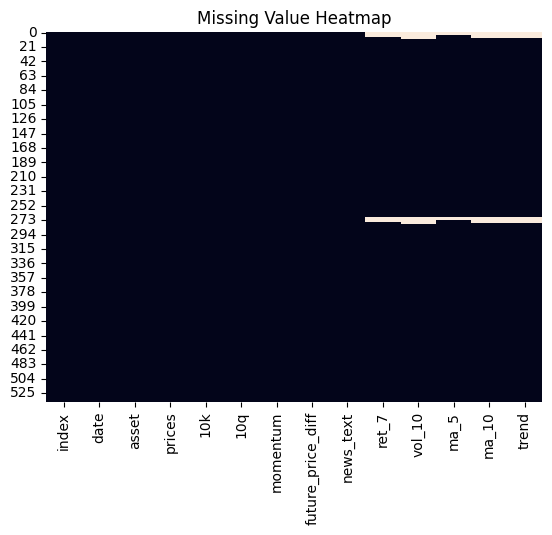

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")

New Features plot

array([[<Axes: title={'center': 'index'}>,
        <Axes: title={'center': 'prices'}>,
        <Axes: title={'center': 'future_price_diff'}>],
       [<Axes: title={'center': 'ret_7'}>,
        <Axes: title={'center': 'vol_10'}>,
        <Axes: title={'center': 'ma_5'}>],
       [<Axes: title={'center': 'ma_10'}>,
        <Axes: title={'center': 'trend'}>, <Axes: >]], dtype=object)

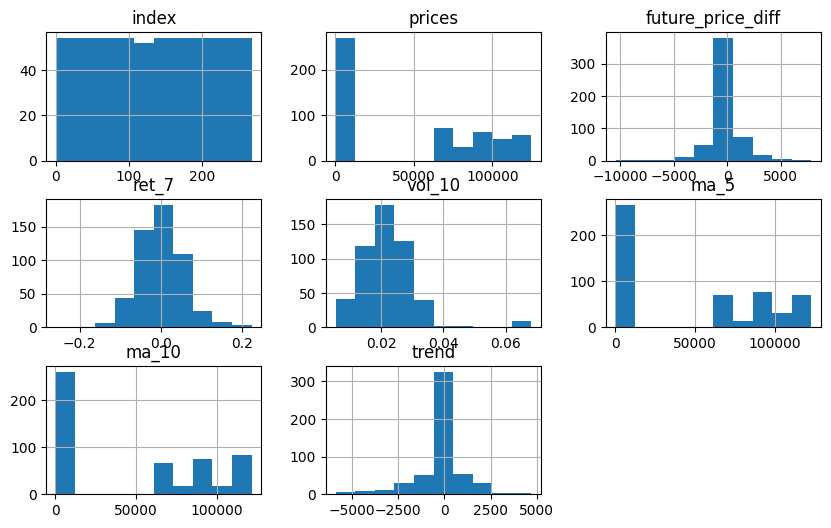

In [ ]:
df.hist(figsize=(10,6))

Price Movement over time

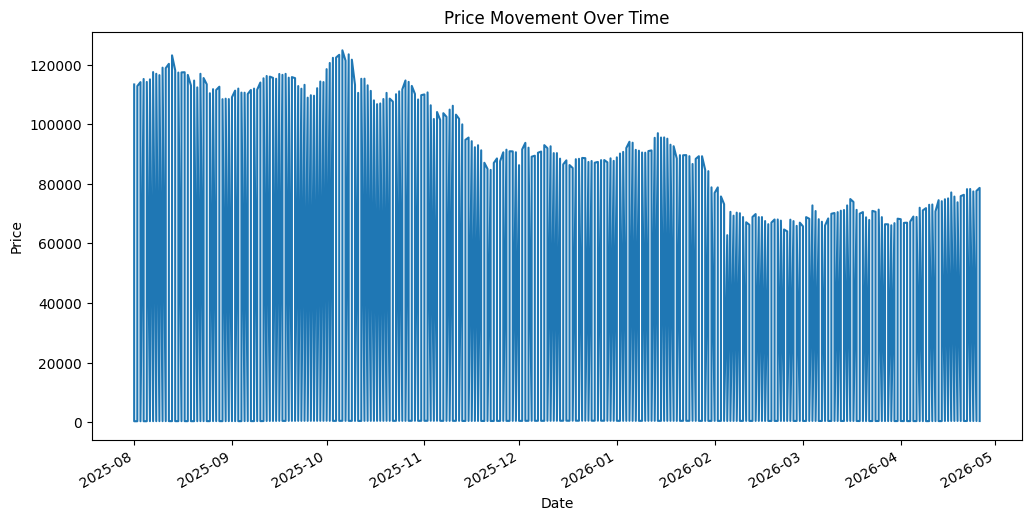

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date')
df.set_index('date', inplace=True)

df['prices'].plot(figsize=(12,6))
plt.title("Price Movement Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

BTC vs TSLA price trend

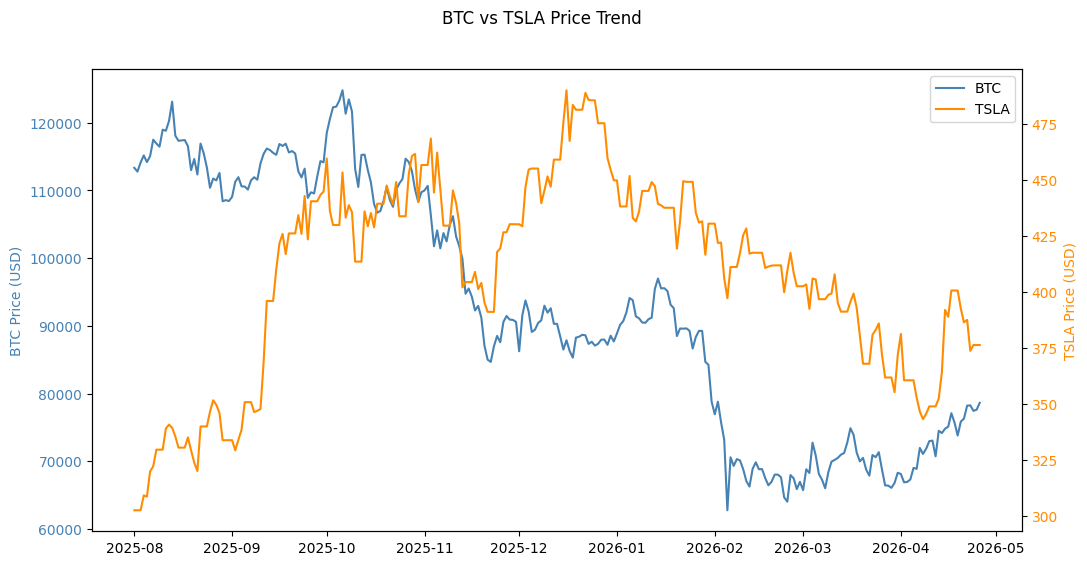

In [ ]:
btc = df[df['asset'] == 'BTC']
tsla = df[df['asset'] == 'TSLA']

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(btc.index, btc['prices'], color='steelblue', label='BTC')
ax1.set_ylabel('BTC Price (USD)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()  # second Y-axis shares the same X-axis
ax2.plot(tsla.index, tsla['prices'], color='darkorange', label='TSLA')
ax2.set_ylabel('TSLA Price (USD)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

fig.suptitle('BTC vs TSLA Price Trend')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.show()

Momentum Distribution

Text(0.5, 1.0, 'Momentum Distribution')

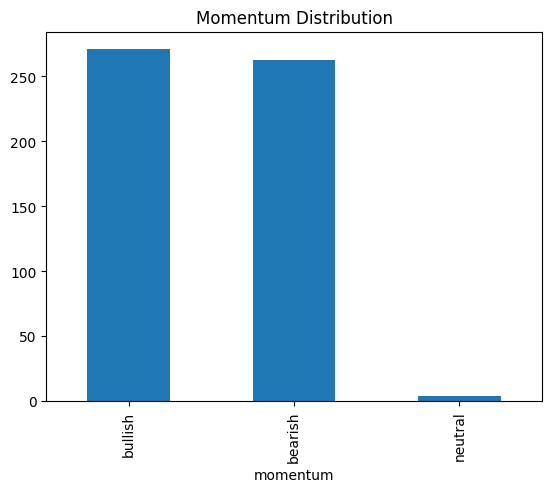

In [ ]:
df['momentum'].value_counts().plot(kind='bar')
plt.title("Momentum Distribution")

Future Price Difference Distribution

Text(0.5, 1.0, 'Future Price Difference Distribution')

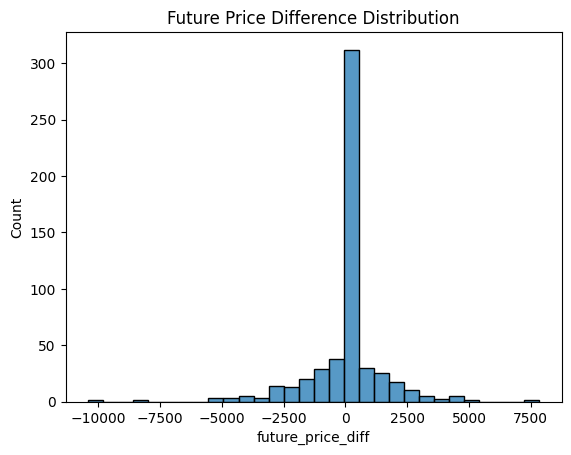

In [ ]:
sns.histplot(df['future_price_diff'], bins=30)
plt.title("Future Price Difference Distribution")

Number of news articles each day

Text(0.5, 1.0, 'News Articles Per Day')

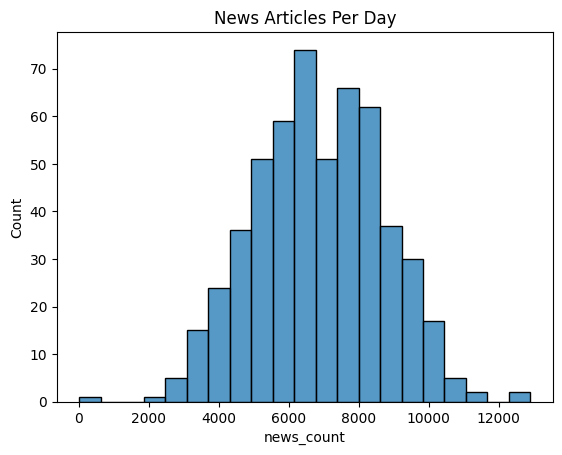

In [ ]:
df['news_count'] = df['news_text'].apply(len)
sns.histplot(df['news_count'])
plt.title("News Articles Per Day")

In [ ]:
!pip install nltk

## Vader Sentiment

In [ ]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
sia = SentimentIntensityAnalyzer()
df['sentiment'] = df['news_text'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

-1 → very negative

0 → neutral

+1 → very positive

Overall Sentiment - Both Assets

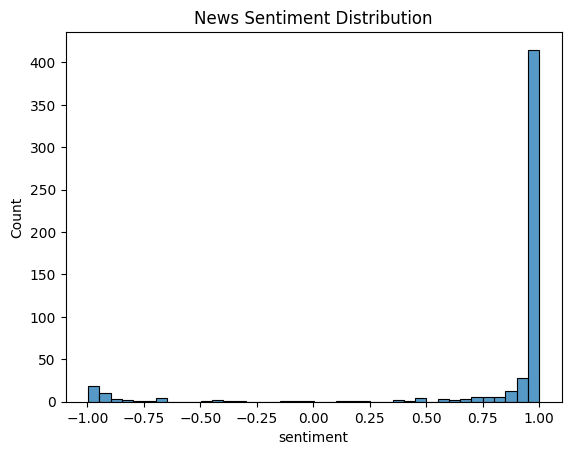

In [ ]:
sns.histplot(df['sentiment'], bins=40)
plt.title("News Sentiment Distribution")
plt.show()

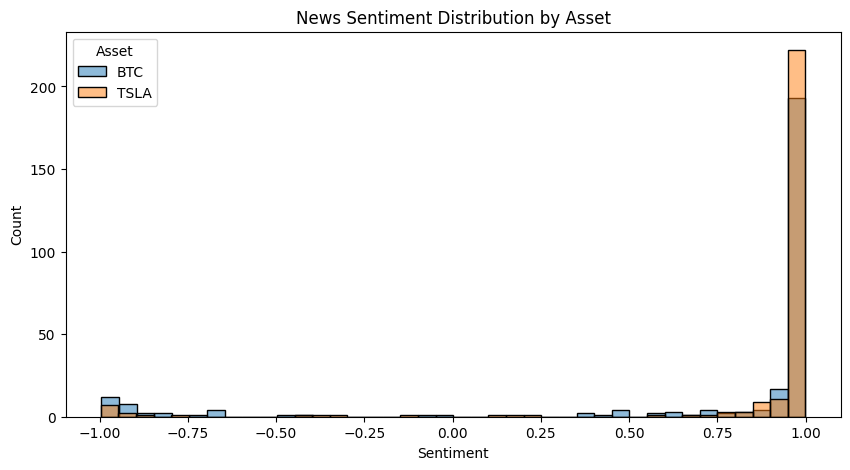

In [ ]:
plt.figure(figsize=(10, 5))
for asset in df['asset'].unique():
    subset = df[df['asset'] == asset]
    sns.histplot(subset['sentiment'], bins=40, label=asset, alpha=0.5)

plt.title("News Sentiment Distribution by Asset")
plt.xlabel("Sentiment")
plt.legend(title="Asset")
plt.show()

Sentiment vs Future Price change

Text(0.5, 1.0, 'Sentiment vs Future Price Change')

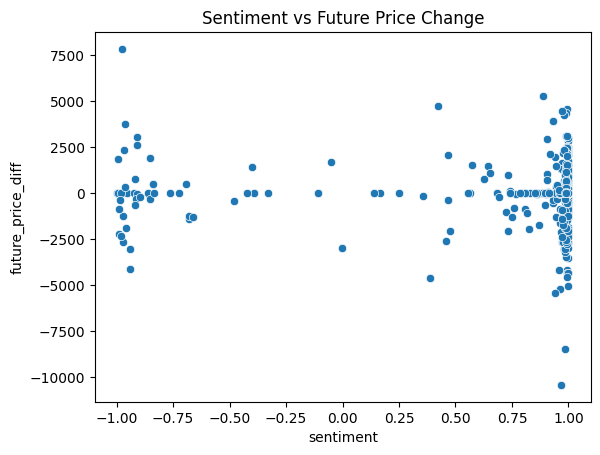

In [ ]:
sns.scatterplot(
    data=df,
    x='sentiment',
    y='future_price_diff'
)
plt.title("Sentiment vs Future Price Change")

Market momentum by sentiment

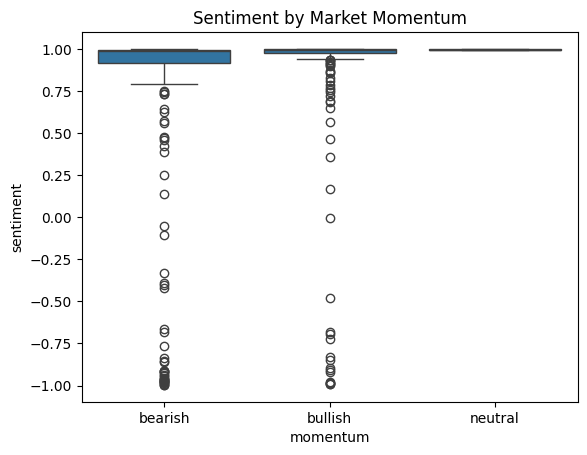

In [ ]:
sns.boxplot(x='momentum', y='sentiment', data=df)
plt.title("Sentiment by Market Momentum")
plt.show()

Price Difference Distribution by Asset

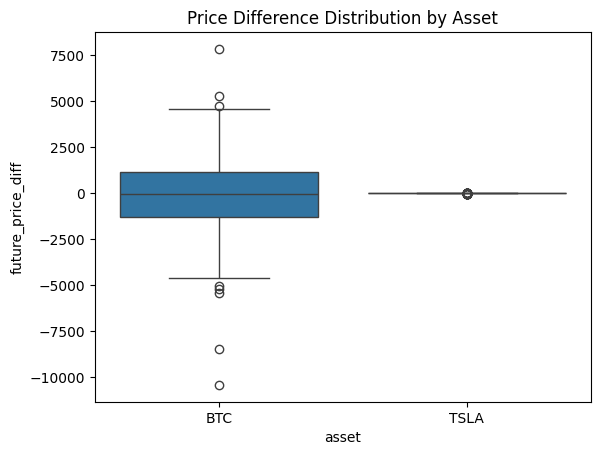

In [ ]:
sns.boxplot(x='asset', y='future_price_diff', data=df)
plt.title("Price Difference Distribution by Asset")
plt.show()

Feature Correlation plot

Text(0.5, 1.0, 'Feature Correlation')

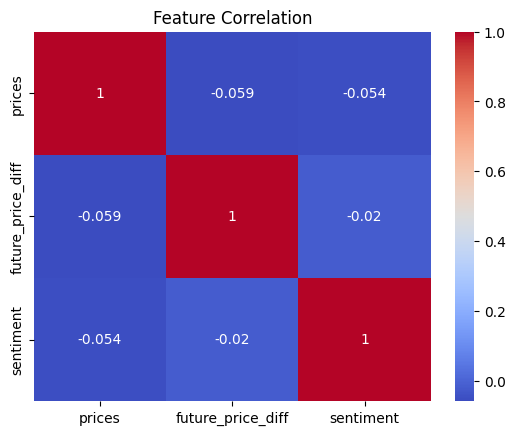

In [ ]:
features = df[['prices','future_price_diff','sentiment']]
sns.heatmap(features.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")

In [ ]:
df = df.reset_index()

## FinBERT Sentiment

In [ ]:
from transformers import pipeline

finbert_sentiment = pipeline("sentiment-analysis", model="yiyanghkust/finbert-tone")

def get_finbert_score(text):
    result = finbert_sentiment(text[:512])[0]

    label = result['label']
    score = result['score']  # confidence

    if label == 'positive':
        return score
    elif label == 'negative':
        return -score
    else:
        return 0

df['finbert_sentiment'] = df['news_text'].apply(get_finbert_score)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-tone
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Feature Preparation

In [ ]:
# ---------- 1) Start from a clean dataframe ----------
base_df = df.copy()

# If date is not already datetime
base_df['date'] = pd.to_datetime(base_df['date'])

# Sort by asset and date
base_df = base_df.sort_values(['asset', 'date']).reset_index(drop=True)

# Optional: drop mostly useless filing columns for baseline
# Keep them for later advanced modeling if you want
drop_cols = [c for c in ['10k', '10q'] if c in base_df.columns]
base_df = base_df.drop(columns=drop_cols, errors='ignore')

# ---------- 2) Better missing-value handling ----------
base_df['future_price_diff'] = pd.to_numeric(base_df['future_price_diff'], errors='coerce')
base_df['prices'] = pd.to_numeric(base_df['prices'], errors='coerce')
base_df['sentiment'] = pd.to_numeric(base_df['sentiment'], errors='coerce')

# base_df = base_df.dropna(subset=['date', 'asset', 'prices', 'future_price_diff', 'sentiment']).copy()

# ---------- 3) Engineer asset-aware features ----------
base_df['future_return'] = base_df['future_price_diff'] / base_df['prices']

base_df['ret_1'] = base_df.groupby('asset')['prices'].pct_change(1)

base_df['ret_3'] = (
    base_df.groupby('asset')['prices']
    .pct_change()
    .groupby(base_df['asset'])
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

base_df['ret_7'] = base_df.groupby('asset')['prices'].pct_change(7)

base_df['vol_5'] = (
    base_df.groupby('asset')['prices']
    .pct_change()
    .groupby(base_df['asset'])
    .rolling(5)
    .std()
    .reset_index(level=0, drop=True)
)

base_df['vol_10'] = (
    base_df.groupby('asset')['prices']
    .pct_change()
    .groupby(base_df['asset'])
    .rolling(10)
    .std()
    .reset_index(level=0, drop=True)
)

base_df['ma_5'] = base_df.groupby('asset')['prices'].rolling(5).mean().reset_index(level=0, drop=True)
base_df['ma_10'] = base_df.groupby('asset')['prices'].rolling(10).mean().reset_index(level=0, drop=True)

base_df['trend'] = base_df['ma_5'] - base_df['ma_10']

base_df['text_len'] = base_df['news_text'].fillna('').str.len()
base_df['sentiment_change'] = base_df.groupby('asset')['finbert_sentiment'].diff()
base_df['momentum_strength'] = base_df['ret_1'] * base_df['vol_5']
base_df['return_to_vol'] = base_df['ret_1'] / (base_df['vol_5'] + 1e-6)

# ✅ DROP NaNs HERE (CORRECT PLACE)
feature_cols_all = [
    'ret_1','ret_3','ret_7',
    'vol_5','vol_10',
    'ma_5','ma_10','trend'
]

# base_df = base_df.dropna(subset=feature_cols_all).copy()
base_df = base_df.groupby('asset').apply(lambda x: x.iloc[10:]).reset_index(drop=True)
print(base_df.shape)

# ---------- 5) Chronological train/test split ----------
# Split per asset to avoid future leakage
train_parts = []
test_parts = []

base_df = base_df.dropna(subset=feature_cols_all)

for asset_name, g in base_df.groupby('asset'):
    g = g.sort_values('date').reset_index(drop=True)
    split_idx = int(len(g) * 0.8)
    train_parts.append(g.iloc[:split_idx])
    test_parts.append(g.iloc[split_idx:])

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

# ---------- 6) Build thresholds on TRAIN ONLY ----------
# Balanced 3-class split using train quantiles
q_low = train_df['future_return'].quantile(0.27)
q_high = train_df['future_return'].quantile(0.73)

def make_action_label(x, low, high):
    if x <= low:
        return 'SELL'
    elif x >= high:
        return 'BUY'
    else:
        return 'HOLD'

train_df['action'] = train_df['future_return'].apply(lambda x: make_action_label(x, q_low, q_high))
test_df['action'] = test_df['future_return'].apply(lambda x: make_action_label(x, q_low, q_high))

train_df['sentiment_volatility'] = train_df.groupby('asset')['finbert_sentiment'].rolling(3).std().reset_index(level=0, drop=True)
test_df['sentiment_volatility'] = test_df.groupby('asset')['finbert_sentiment'].rolling(3).std().reset_index(level=0, drop=True)

# ---------- 7) Prepare features ----------
feature_cols_num = ['sentiment', 'finbert_sentiment','ma_5', 'ma_10', 'ret_1', 'ret_3', 'ret_7', 'vol_5', 'vol_10', 'trend',
                    'text_len', 'sentiment_change', 'momentum_strength', 'return_to_vol']

feature_cols_cat = ['asset', 'momentum']
feature_cols_all = ['ret_7', 'vol_10', 'ma_5', 'ma_10', 'trend']

X_train = train_df[feature_cols_num + feature_cols_cat]
y_train = train_df['action']

X_test = test_df[feature_cols_num + feature_cols_cat]
y_test = test_df['action']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, feature_cols_num),
    ('cat', categorical_transformer, feature_cols_cat)
])

(518, 23)


/tmp/ipykernel_580/2680830053.py:74: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  base_df = base_df.groupby('asset').apply(lambda x: x.iloc[10:]).reset_index(drop=True)


## Logistic Regression

In [ ]:
baseline_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        multi_class='multinomial',
        class_weight='balanced',
        random_state=42
    ))
])

baseline_clf.fit(X_train, y_train)

# ---------- 8) Evaluate -----------
y_pred = baseline_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred, labels=['SELL', 'HOLD', 'BUY']))

Accuracy: 0.3269230769230769
Macro F1: 0.3153817732421103
              precision    recall  f1-score   support

         BUY       0.24      0.48      0.32        25
        HOLD       0.55      0.31      0.40        52
        SELL       0.25      0.22      0.24        27

    accuracy                           0.33       104
   macro avg       0.35      0.34      0.32       104
weighted avg       0.40      0.33      0.33       104

Confusion matrix:
 [[ 6  6 15]
 [12 16 24]
 [ 6  7 12]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


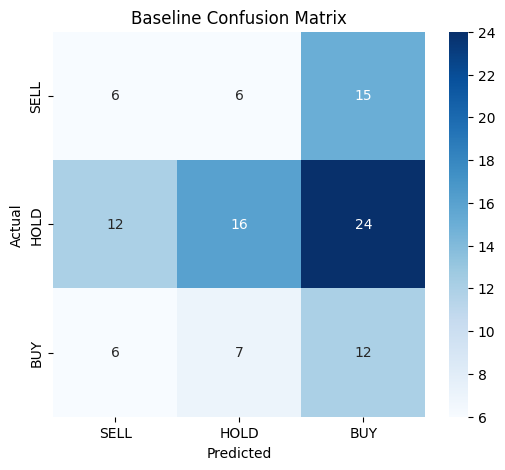

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=['SELL', 'HOLD', 'BUY'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['SELL', 'HOLD', 'BUY'],
            yticklabels=['SELL', 'HOLD', 'BUY'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline Confusion Matrix")
plt.show()

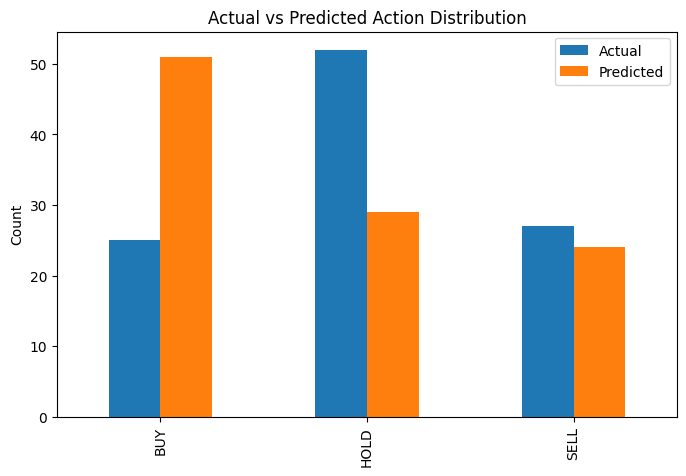

In [ ]:
pred_dist = pd.Series(y_pred).value_counts().sort_index()
true_dist = y_test.value_counts().sort_index()

plot_df = pd.DataFrame({
    'Actual': true_dist,
    'Predicted': pred_dist
}).fillna(0)

plot_df.plot(kind='bar', figsize=(8, 5))
plt.title("Actual vs Predicted Action Distribution")
plt.ylabel("Count")
plt.show()

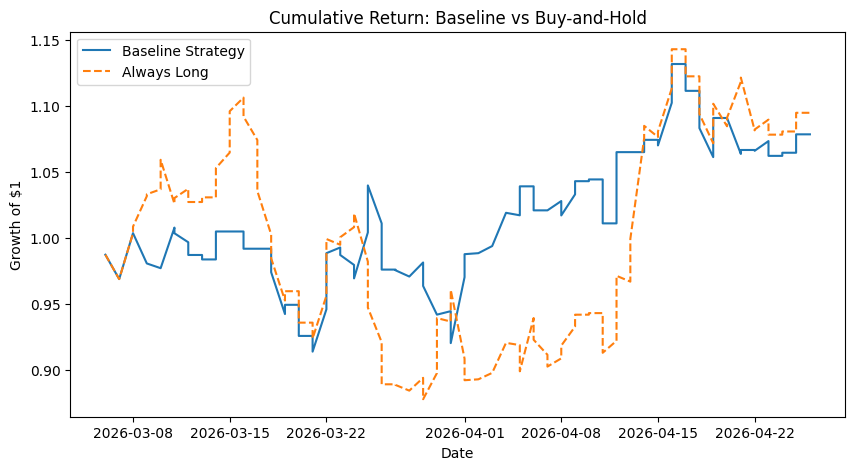

In [ ]:
test_results = test_df.copy()
test_results['pred_action'] = y_pred

action_to_pos = {'SELL': -1, 'HOLD': 0, 'BUY': 1}
test_results['position'] = test_results['pred_action'].map(action_to_pos)

# realized future return already available
test_results['strategy_return'] = test_results['position'] * test_results['future_return']

# portfolio curve across time
test_results = test_results.sort_values('date')
test_results['cum_strategy'] = (1 + test_results['strategy_return']).cumprod()
test_results['cum_buy_hold'] = (1 + test_results['future_return']).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(test_results['date'], test_results['cum_strategy'], label='Baseline Strategy')
plt.plot(test_results['date'], test_results['cum_buy_hold'], label='Always Long', linestyle='--')
plt.legend()
plt.title("Cumulative Return: Baseline vs Buy-and-Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.show()

## XGBoost Classifier

In [ ]:
xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=3,
    random_state=42
)

# # Fit using preprocessed pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_clf)
])
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
xgb_pipeline.fit(X_train, y_train_encoded)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_test_encoded = le.transform(y_test)

y_pred_labels = le.inverse_transform(y_pred_xgb)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_labels))
print("XGBoost Macro F1:", f1_score(y_test, y_pred_labels, average='macro'))

print(classification_report(y_test, y_pred_labels))

XGBoost Accuracy: 0.4519230769230769
XGBoost Macro F1: 0.36483725350439533
              precision    recall  f1-score   support

         BUY       0.27      0.16      0.20        25
        HOLD       0.51      0.69      0.59        52
        SELL       0.37      0.26      0.30        27

    accuracy                           0.45       104
   macro avg       0.38      0.37      0.36       104
weighted avg       0.42      0.45      0.42       104



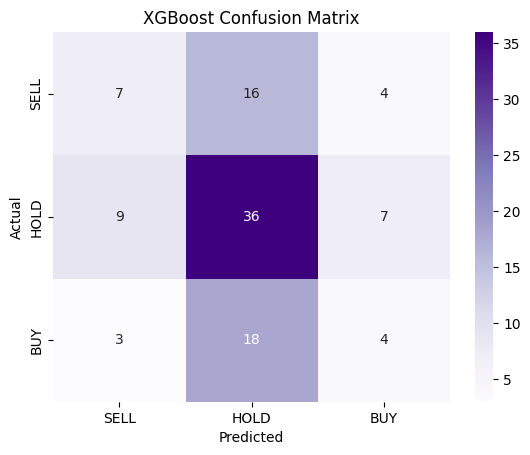

In [ ]:
cm = confusion_matrix(y_test, y_pred_labels, labels=['SELL','HOLD','BUY'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['SELL','HOLD','BUY'],
            yticklabels=['SELL','HOLD','BUY'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

## FinBERT

In [ ]:
from transformers import AutoTokenizer, AutoModel

finbert_model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(finbert_model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embedding_model = AutoModel.from_pretrained(finbert_model_name)
embedding_model.to(device)
embedding_model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
model = AutoModel.from_pretrained(finbert_model_name)
model.to(device)   # ✅ IMPORTANT
model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
def get_finbert_embedding(text):
    inputs = tokenizer(
        str(text),
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = embedding_model(**inputs)   # use embedding_model

    embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

    return embedding

In [ ]:
train_df_sample = train_df.copy()
test_df_sample = test_df.copy()

train_embeddings = np.vstack(
    train_df_sample['news_text'].apply(get_finbert_embedding)
)

test_embeddings = np.vstack(
    test_df_sample['news_text'].apply(get_finbert_embedding)
)

In [ ]:
pca = PCA(n_components=20)

train_embeddings = pca.fit_transform(train_embeddings)
test_embeddings = pca.transform(test_embeddings)

In [ ]:
print("train_df:", train_df_sample.shape)
print("train_embeddings:", train_embeddings.shape)

print("test_df:", test_df_sample.shape)
print("test_embeddings:", test_embeddings.shape)

train_df: (414, 25)
train_embeddings: (414, 20)
test_df: (104, 25)
test_embeddings: (104, 20)


In [ ]:
scaler_num = StandardScaler()
scaler = StandardScaler()
X_train_num = scaler_num.fit_transform(train_df_sample[feature_cols_num].values)
X_test_num = scaler_num.transform(test_df_sample[feature_cols_num].values)

# ================= FINBERT PROBABILITIES =================

from transformers import pipeline

finbert_classifier = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    return_all_scores=True,
    top_k=None
)

def get_finbert_probs(text):
    results = finbert_classifier(str(text)[:512])

    # Case 1: returns list of list (expected)
    if isinstance(results[0], list):
        results = results[0]
        scores = {r['label'].lower(): r['score'] for r in results}

        return [
            scores.get('positive', 0),
            scores.get('neutral', 0),
            scores.get('negative', 0)
        ]

    # Case 2: returns single dict
    elif isinstance(results[0], dict):
        label = results[0]['label'].lower()
        score = results[0]['score']

        return [
            score if label == 'positive' else 0,
            score if label == 'neutral' else 0,
            score if label == 'negative' else 0
        ]

    # Case 3: unexpected
    else:
        return [0, 0, 0]

# Generate features
train_probs = np.array(train_df_sample['news_text'].apply(get_finbert_probs).tolist())
test_probs = np.array(test_df_sample['news_text'].apply(get_finbert_probs).tolist())

# Combine with numeric features
X_train_final = np.hstack([
    X_train_num,
    train_embeddings * 1.5,
    train_probs
])

X_test_final = np.hstack([
    X_test_num,
    test_embeddings * 1.5,   # CORRECT
    test_probs
])

# Scale
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_final)
X_test_final = scaler.transform(X_test_final)

# Combine
# X_train_final = np.hstack([X_train_num, train_embeddings])
# X_test_final = np.hstack([X_test_num, test_embeddings])

# X_train_final = scaler.fit_transform(X_train_final)
# X_test_final = scaler.transform(X_test_final)

# y_train = train_df_sample['action']
# y_test = test_df_sample['action']

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode labels
le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['action'])
test_df['label'] = le.transform(test_df['action'])

num_labels = len(le.classes_)

model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

# Convert to HuggingFace dataset
train_dataset = Dataset.from_pandas(train_df[['news_text', 'label']])
test_dataset = Dataset.from_pandas(test_df[['news_text', 'label']])

# Tokenize
def tokenize(example):
    return tokenizer(example["news_text"],
                     truncation=True,
                     padding="max_length",
                     max_length=128)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])
test_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])

# Training
training_args = TrainingArguments(
    output_dir="./finbert_only",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    # evaluation_strategy="epoch",
    logging_steps=50,
    report_to="none"
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

results = trainer.evaluate()
print("FinBERT ONLY:", results)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Map:   0%|          | 0/414 [00:00<?, ? examples/s]

Map:   0%|          | 0/104 [00:00<?, ? examples/s]

Step,Training Loss
50,1.189061
100,1.071585
150,1.068989


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

FinBERT ONLY: {'eval_loss': 1.0396506786346436, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.2222222222222222, 'eval_runtime': 0.8347, 'eval_samples_per_second': 124.592, 'eval_steps_per_second': 15.574, 'epoch': 3.0}


## FinBERT - Logistic Regression

In [ ]:
finbert_clf = LogisticRegression(
    max_iter=80000,
    multi_class='multinomial',
    class_weight='balanced'
)

finbert_clf.fit(X_train_final, y_train)
y_pred_finbert = finbert_clf.predict(X_test_final)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


FinBERT Accuracy: 0.3557692307692308
FinBERT Macro F1: 0.33667711598746086
              precision    recall  f1-score   support

         BUY       0.22      0.36      0.27        25
        HOLD       0.60      0.40      0.48        52
        SELL       0.25      0.26      0.25        27

    accuracy                           0.36       104
   macro avg       0.36      0.34      0.34       104
weighted avg       0.42      0.36      0.37       104



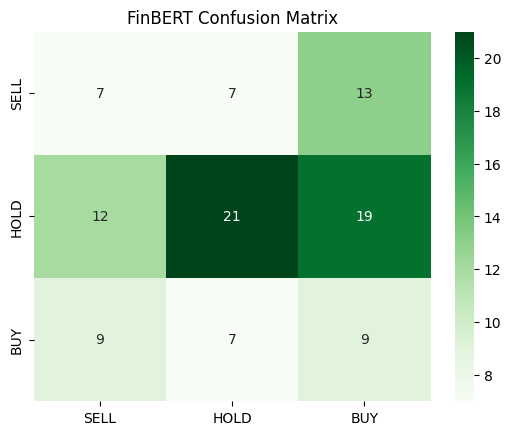

In [ ]:
print("FinBERT Accuracy:", accuracy_score(y_test, y_pred_finbert))
print("FinBERT Macro F1:", f1_score(y_test, y_pred_finbert, average='macro'))

print(classification_report(y_test, y_pred_finbert))

cm = confusion_matrix(y_test, y_pred_finbert, labels=['SELL','HOLD','BUY'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['SELL','HOLD','BUY'],
            yticklabels=['SELL','HOLD','BUY'])
plt.title("FinBERT Confusion Matrix")
plt.show()

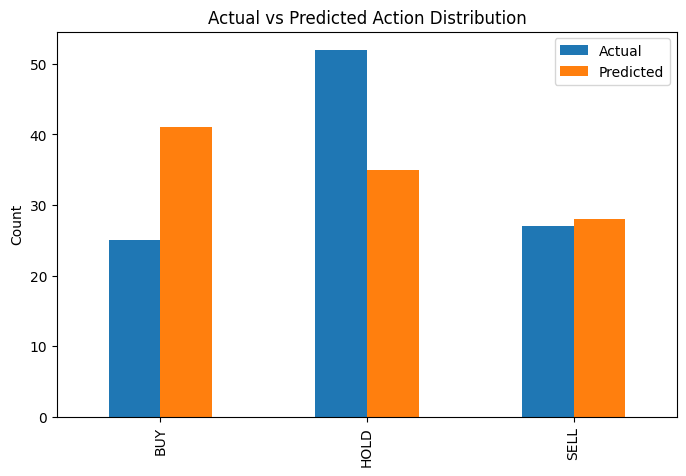

In [ ]:
pred_dist = pd.Series(y_pred_finbert).value_counts().sort_index()
true_dist = y_test.value_counts().sort_index()

plot_df = pd.DataFrame({
    'Actual': true_dist,
    'Predicted': pred_dist
}).fillna(0)

plot_df.plot(kind='bar', figsize=(8, 5))
plt.title("Actual vs Predicted Action Distribution")
plt.ylabel("Count")
plt.show()

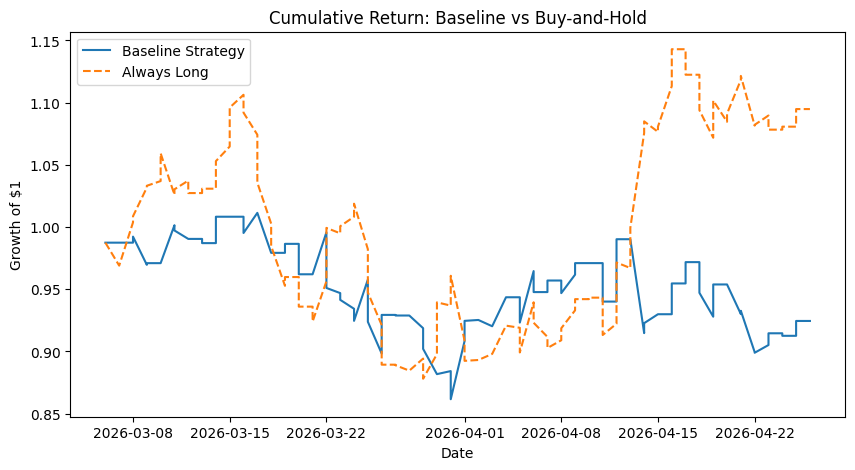

In [ ]:
test_results = test_df.copy()
test_results['pred_action'] = y_pred_finbert

action_to_pos = {'SELL': -1, 'HOLD': 0, 'BUY': 1}
test_results['position'] = test_results['pred_action'].map(action_to_pos)

# realized future return already available
test_results['strategy_return'] = test_results['position'] * test_results['future_return']

# portfolio curve across time
test_results = test_results.sort_values('date')
test_results['cum_strategy'] = (1 + test_results['strategy_return']).cumprod()
test_results['cum_buy_hold'] = (1 + test_results['future_return']).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(test_results['date'], test_results['cum_strategy'], label='Baseline Strategy')
plt.plot(test_results['date'], test_results['cum_buy_hold'], label='Always Long', linestyle='--')
plt.legend()
plt.title("Cumulative Return: Baseline vs Buy-and-Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.show()

## FinBERT - XGB

In [ ]:
# fine tuned
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from xgboost import callback
from xgboost.callback import EarlyStopping

# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Compute class weights

class_weights = {
    0: 1.0,
    1: 1.0,
    2: 2.0   # boost BUY
}

sample_weights = np.array([class_weights[y] for y in y_train_encoded])

# Model
# xgb_finbert = XGBClassifier(
#     n_estimators=250,
#     max_depth=4,
#     learning_rate=0.08,
#     subsample=0.85,
#     colsample_bytree=0.85,
#     gamma=0.1,
#     min_child_weight=3,
#     reg_lambda=1.5,
#     objective='multi:softprob',
#     num_class=3,
#     random_state=42
# )
# optimization
# xgb_finbert = XGBClassifier(
#     # n_estimators=300,
#     n_estimators=250,
#     max_depth=3,              # ↓ simpler = less overfitting
#     learning_rate=0.07,       # balanced learning
#     subsample=0.9,
#     colsample_bytree=0.9,
#     gamma=0.05,
#     min_child_weight=5,       # more regularization
#     reg_lambda=2.0,           # stronger L2
#     reg_alpha=0.5,            # L1 regularization
#     objective='multi:softprob',
#     num_class=3,
#     random_state=42
# )

# # Further optimization
# xgb_finbert = XGBClassifier(
#     n_estimators=300,
#     max_depth=4,
#     learning_rate=0.05,
#     subsample=0.85,
#     colsample_bytree=0.85,
#     gamma=0.1,
#     min_child_weight=3,
#     reg_lambda=2.0,
#     reg_alpha=0.5,
#     objective='multi:softprob',
#     num_class=3,
#     random_state=42
# )

# More optimized
xgb_finbert = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.04,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.05,
    min_child_weight=4,
    reg_lambda=2,
    reg_alpha=0.5,
    objective='multi:softprob',
    num_class=3,
    random_state=42
)

# ✅ Train correctly
# xgb_finbert.fit(X_train_final, y_train_encoded, sample_weight=sample_weights)
xgb_finbert.fit(
    X_train_final,
    y_train_encoded,
    sample_weight=sample_weights,
    eval_set=[(X_test_final, y_test_encoded)],
    # callbacks=[callback.EarlyStopping(rounds=20)],
    verbose=False
)

# ✅ Predict correctly
y_pred = xgb_finbert.predict(X_test_final)

# Convert back
y_pred_labels = le.inverse_transform(y_pred)

# Evaluate
print("FinBERT + XGB Accuracy:", accuracy_score(y_test, y_pred_labels))
print("Macro F1:", f1_score(y_test, y_pred_labels, average='macro'))
print(classification_report(y_test, y_pred_labels))

FinBERT + XGB Accuracy: 0.40384615384615385
Macro F1: 0.3236295867874815
              precision    recall  f1-score   support

         BUY       0.21      0.12      0.15        25
        HOLD       0.53      0.62      0.57        52
        SELL       0.23      0.26      0.25        27

    accuracy                           0.40       104
   macro avg       0.33      0.33      0.32       104
weighted avg       0.38      0.40      0.39       104



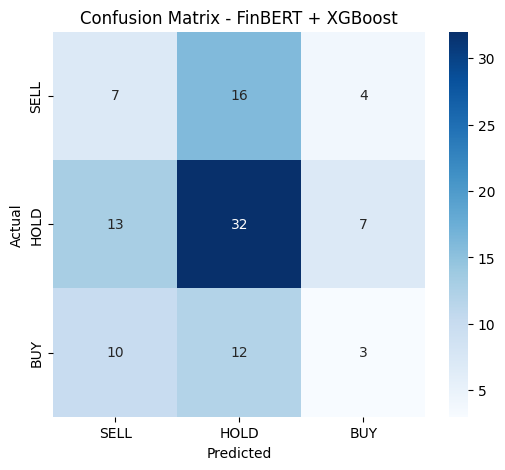

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm_finbert = confusion_matrix(y_test, y_pred_labels, labels=['SELL', 'HOLD', 'BUY'])

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm_finbert,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['SELL','HOLD','BUY'],
            yticklabels=['SELL','HOLD','BUY'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - FinBERT + XGBoost")
plt.show()

## Fusion model

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Compute class weights
classes = np.unique(y_train_encoded)
weights = compute_class_weight('balanced', classes=classes, y=y_train_encoded)
class_weights = dict(zip(classes, weights))
sample_weights = np.array([class_weights[y] for y in y_train_encoded])

# 🔥 OPTIMIZED MODEL
xgb_final = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    min_child_weight=5,
    reg_lambda=3,
    reg_alpha=1,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

xgb_final.fit(
    X_train_final,
    y_train_encoded,
    sample_weight=sample_weights,
    eval_set=[(X_test_final, y_test_encoded)],
    # early_stopping_rounds=25,
    verbose=False
)

# Predictions
y_pred = xgb_final.predict(X_test_final)
y_pred_labels = le.inverse_transform(y_pred)

print("🔥 FINAL Accuracy:", accuracy_score(y_test, y_pred_labels))
print("🔥 FINAL F1:", f1_score(y_test, y_pred_labels, average='macro'))
print(classification_report(y_test, y_pred_labels))

🔥 FINAL Accuracy: 0.3269230769230769
🔥 FINAL F1: 0.27138406148307137
              precision    recall  f1-score   support

         BUY       0.15      0.16      0.15        25
        HOLD       0.53      0.50      0.51        52
        SELL       0.14      0.15      0.15        27

    accuracy                           0.33       104
   macro avg       0.27      0.27      0.27       104
weighted avg       0.34      0.33      0.33       104



In [ ]:
# ================= STACKING =================

from sklearn.linear_model import LogisticRegression

# Get XGB probabilities
xgb_probs_train = xgb_final.predict_proba(X_train_final)
xgb_probs_test = xgb_final.predict_proba(X_test_final)

# Meta model
meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(xgb_probs_train, y_train)

# Final prediction
y_pred_meta = meta_model.predict(xgb_probs_test)

print("🚀 STACKED Accuracy:", accuracy_score(y_test, y_pred_meta))
print("🚀 STACKED F1:", f1_score(y_test, y_pred_meta, average='macro'))

🚀 STACKED Accuracy: 0.34615384615384615
🚀 STACKED F1: 0.23884802791033133


## Test

Case 1

In [ ]:
# ================= SINGLE SAMPLE PREDICTION =================

sample_input = {
    "asset": "TSLA",
    # "news_text": "Tesla reports weaker than expected vehicle deliveries and no improved margins.",
    "news_text": "Tesla reports bankrutpcy.",

    # numeric features expected by your final model
    "sentiment": 0.35,
    "finbert_sentiment": 0.62,
    "ma_5": 248.50,   # 5-day moving average
    "ma_10": 244.20,  # 10-day moving average
    "ret_1": 0.012,
    "ret_3": 0.025,
    "ret_7": 0.041,
    "vol_5": 0.018,
    "vol_10": 0.022,
    "trend": 4.15,
    "text_len": len("Tesla reports bankrutpcy."),
    "sentiment_change": 0.10,
    "momentum_strength": 0.012 * 0.018,
    "return_to_vol": 0.012 / (0.018 + 1e-6),
}

# sample_df = test_df_sample.iloc[[50]]
# sample_df["news_text"]: "Tesla reports bankrutpcy."
sample_df = pd.DataFrame([sample_input])

# for i in [10, 25, 50, 75]:
#     sample_df = test_df_sample.iloc[[i]].copy()

# -----------------------------
# 1. numeric features
# -----------------------------
sample_num = scaler_num.transform(sample_df[feature_cols_num].values)

# -----------------------------
# 2. FinBERT embedding
# -----------------------------
sample_embedding = np.vstack(
    sample_df["news_text"].apply(get_finbert_embedding)
)
sample_embedding = pca.transform(sample_embedding)

# -----------------------------
# 3. FinBERT probabilities
# -----------------------------
sample_probs = np.array(
    sample_df["news_text"].apply(get_finbert_probs).tolist()
)

# -----------------------------
# 4. final feature stack
# -----------------------------
sample_final = np.hstack([
    sample_num,
    sample_embedding,
    sample_probs
])

sample_final = scaler.transform(sample_final)

# -----------------------------
# 5. predict
# -----------------------------
pred_encoded = xgb_final.predict(sample_final)[0]
pred_label = le.inverse_transform([pred_encoded])[0]

pred_proba = xgb_final.predict_proba(sample_final)[0]
class_probs = dict(zip(le.classes_, pred_proba))

print("Predicted action:", pred_label)
print("Class probabilities:", class_probs)

Predicted action: SELL
Class probabilities: {'BUY': np.float32(0.19592673), 'HOLD': np.float32(0.29340917), 'SELL': np.float32(0.5106641)}


Case 2

In [ ]:
sample_input = {
    "asset": "TSLA",
    "news_text": "Tesla faces major losses and declining demand concerns.",

    "sentiment": -0.8,
    "finbert_sentiment": -0.9,
    "ma_5": 232.10,   # 5-day avg below 10-day (bearish crossover)
    "ma_10": 244.10,  # 10-day avg still elevated
    "ret_1": -0.04,
    "ret_3": -0.07,
    "ret_7": -0.1,
    "vol_5": 0.03,
    "vol_10": 0.035,
    "trend": -12.0,
    "text_len": 75,
    "sentiment_change": -0.3,
    "momentum_strength": -0.04 * 0.03,
    "return_to_vol": -0.04 / (0.03 + 1e-6),
}
sample_df = pd.DataFrame([sample_input])

# sample_df = test_df_sample.iloc[[50]]
# sample_df["news_text"]: "Tesla faces major losses and declining demand concerns."
# # sample_df = pd.DataFrame([sample_input])

# for i in [10, 25, 50, 75]:
#     sample_df = test_df_sample.iloc[[i]].copy()

# -----------------------------
# 1. numeric features
# -----------------------------
sample_num = scaler_num.transform(sample_df[feature_cols_num].values)

# -----------------------------
# 2. FinBERT embedding
# -----------------------------
sample_embedding = np.vstack(
    sample_df["news_text"].apply(get_finbert_embedding)
)
sample_embedding = pca.transform(sample_embedding)

# -----------------------------
# 3. FinBERT probabilities
# -----------------------------
sample_probs = np.array(
    sample_df["news_text"].apply(get_finbert_probs).tolist()
)

# -----------------------------
# 4. final feature stack
# -----------------------------
sample_final = np.hstack([
    sample_num,
    sample_embedding,
    sample_probs
])

sample_final = scaler.transform(sample_final)

# -----------------------------
# 5. predict
# -----------------------------
pred_encoded = xgb_final.predict(sample_final)[0]
pred_label = le.inverse_transform([pred_encoded])[0]

pred_proba = xgb_final.predict_proba(sample_final)[0]
class_probs = dict(zip(le.classes_, pred_proba))

print("Predicted action:", pred_label)
print("Class probabilities:", class_probs)

Predicted action: BUY
Class probabilities: {'BUY': np.float32(0.67015237), 'HOLD': np.float32(0.05618498), 'SELL': np.float32(0.27366263)}


Case 3

In [ ]:
# sample_row = test_df_sample.iloc[[50]]
sample_input = {
    "asset": "TSLA",
    "news_text": "Tesla reports record-breaking earnings and massive growth outlook.",

    "sentiment": 0.8,
    "finbert_sentiment": 0.9,
    "ma_5": 263.50,   # 5-day avg above 10-day (bullish crossover)
    "ma_10": 248.50,  # 10-day avg lagging behind
    "ret_1": 0.05,
    "ret_3": 0.08,
    "ret_7": 0.12,
    "vol_5": 0.02,
    "vol_10": 0.025,
    "trend": 15.0,
    "text_len": 80,
    "sentiment_change": 0.3,
    "momentum_strength": 0.05 * 0.02,
    "return_to_vol": 0.05 / (0.02 + 1e-6),
}

# for i in [10, 25, 50, 75]:
#     sample_df = test_df_sample.iloc[[i]].copy()
# sample_df = test_df_sample.iloc[[50]]
# sample_df["news_text"]: "Tesla reports record-breaking earnings and massive growth outlook."
sample_df = pd.DataFrame([sample_input])

# -----------------------------
# 1. numeric features
# -----------------------------
sample_num = scaler_num.transform(sample_df[feature_cols_num].values)

# -----------------------------
# 2. FinBERT embedding
# -----------------------------
sample_embedding = np.vstack(
    sample_df["news_text"].apply(get_finbert_embedding)
)
sample_embedding = pca.transform(sample_embedding)

# -----------------------------
# 3. FinBERT probabilities
# -----------------------------
sample_probs = np.array(
    sample_df["news_text"].apply(get_finbert_probs).tolist()
)

# -----------------------------
# 4. final feature stack
# -----------------------------
sample_final = np.hstack([
    sample_num,
    sample_embedding,
    sample_probs
])

sample_final = scaler.transform(sample_final)

# -----------------------------
# 5. predict
# -----------------------------
pred_encoded = xgb_final.predict(sample_final)[0]
pred_label = le.inverse_transform([pred_encoded])[0]

pred_proba = xgb_final.predict_proba(sample_final)[0]
class_probs = dict(zip(le.classes_, pred_proba))

print("Predicted action:", pred_label)
print("Class probabilities:", class_probs)

Predicted action: HOLD
Class probabilities: {'BUY': np.float32(0.32383567), 'HOLD': np.float32(0.36429432), 'SELL': np.float32(0.31187)}
